### For quick debugging of data files

Inspecting file histos/xl.W_QK.histos.pkl
<class 'histogram_tools.HistogramGroup'>
Inspecting element (0, 0)
<class 'histogram_tools.HistogramBase'>

HistogramBase contains histograms/arrays: dict HistogramBase.histograms
	|---> Key = bins, Object Type = <class 'numpy.ndarray'>
	|---> Key = h, Object Type = <class 'numpy.ndarray'>
	|---> Key = SVD, Object Type = <class 'numpy.ndarray'>

HistogramBase contains stats: dumping HistogramBase.stats_values
	|---> Key = sum, Object Type = <class 'numpy.float32'>
	|---> Key = mean, Object Type = <class 'numpy.float32'>
	|---> Key = std, Object Type = <class 'numpy.float32'>
	|---> Key = max, Object Type = <class 'numpy.float32'>
	|---> Key = min, Object Type = <class 'numpy.float32'>
	|---> Key = skew, Object Type = <class 'numpy.float32'>
	|---> Key = kurtosis, Object Type = <class 'numpy.float32'>

HistogramBase has draw method: calling HistogramBase.draw


AttributeError: Rectangle.set() got an unexpected keyword argument 'title'

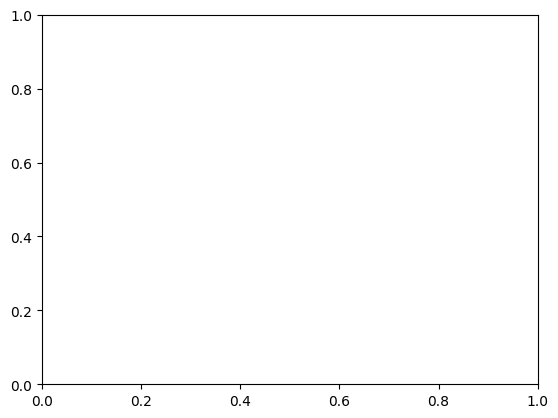

In [ ]:
from histogram_utils import load_group_from_file

def dump_dict(d, prefix='\t|---> '):
    for k, v in d.items():
        print(prefix + f"Key = {k}, Object Type = {type(v)}")


#Load the group of histograms from the file
file_name = "histos/xl.W_QK.histos.pkl"
print(f"Inspecting file {file_name}")
histo_group = load_group_from_file(file_name)

print(type(histo_group))
#HistoGroup
#Has dictionary histogroups: key=(l,h) val=HistogramBase
#Has dictionary metadata: key=(l,h) val=

test_idx = (0, 0) # use 0th head on 0th layer as example
print(f"Inspecting element {test_idx}")
histogram_base = histo_group[test_idx]
print(type(histogram_base))

### HistogramBase

#### Dict `HistogramBase.histograms` (key=str, val="histogram" a 1D np array)
#Access by key:
print("\nHistogramBase contains histograms/arrays: dict HistogramBase.histograms")
dump_dict(histogram_base.histograms)
#The main histogram can be accessed 
h = histogram_base.histograms['h'] #by explicit key
h = histogram_base.hist() #default selected, preferred


#### Dict `HistogramBase.stats_values` (key=str, val=typically, but not always float)
print("\nHistogramBase contains stats: dumping HistogramBase.stats_values")
dump_dict(histogram_base.stats_values)
#Individual stats can be accessed 
stat_mean = histogram_base.stats_values['mean']
stat_mean = histogram_base.get_statistic('mean') #preferred

### function `HistogramBase.draw`
print("\nHistogramBase has draw method: calling HistogramBase.draw")
histogram_base.draw(title = 'test') #or `name='h'`, 
# currently calls plt.bar(), passes kwargs


In [9]:
hm.keys()

dict_keys(['bins', 'h', 'SVD'])

Looking at moments

In [5]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
h = load_group_from_file("test.W_QK.histos.pkl")

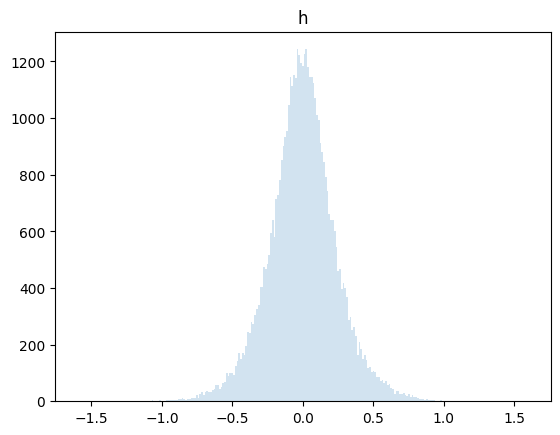

In [11]:
h[0,0].draw()

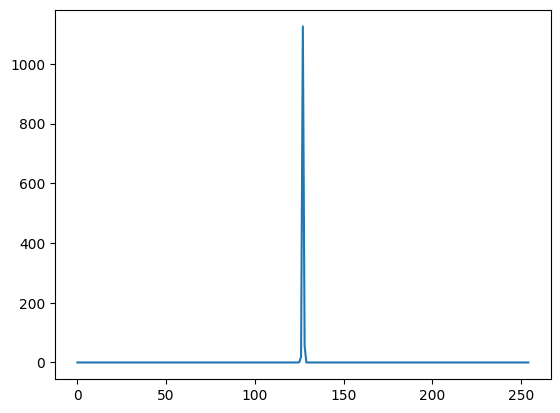

In [ ]:
plt.plot(counts)

In [ ]:
from histogram_utils import *

In [ ]:
kl_vs_empirical_normal(hb[0,0])

np.float64(0.02827215469261634)

In [ ]:
normality_metrics["kl_vs_empirical_normal"](hb[0,0])

np.float64(0.02827215469261634)

In [ ]:
for k,v in normality_metrics.items():
    print(k, v(hb[0,0]))

kl_vs_standard_normal 2.4656522706582567
kl_vs_empirical_normal 0.02827215469261634
kl_normal_vs_standard 2.5563998
fit_normal {'fit_mu': np.float64(-2.0556822101810873e-07), 'fit_sigma': np.float64(0.0400678668323065)}


In [ ]:
extract_metrics(hb[0,0])

{'kl_vs_standard_normal': np.float64(2.4656522706582567),
 'kl_vs_empirical_normal': np.float64(0.02827215469261634),
 'kl_normal_vs_standard': np.float32(2.5563998),
 'fit_normal': {'fit_mu': np.float64(-2.0556822101810873e-07),
  'fit_sigma': np.float64(0.0400678668323065)}}

In [ ]:
for k, v in hb:
    d = extract_metrics(v)
    v.stats_values.update(d)


In [ ]:
hb[0,0].stats_values

{'sum': np.float32(51.854046),
 'mean': np.float32(2.0255487e-05),
 'std': np.float32(0.04710905),
 'max': np.float32(0.5062251),
 'min': np.float32(-0.55945003),
 'skew': np.float32(0.0032705236),
 'kurtosis': np.float32(2.201117),
 'kl_vs_standard_normal': np.float64(2.4656522706582567),
 'kl_vs_empirical_normal': np.float64(0.02827215469261634),
 'kl_normal_vs_standard': np.float32(2.5563998),
 'fit_normal': {'fit_mu': np.float64(-2.0556822101810873e-07),
  'fit_sigma': np.float64(0.0400678668323065)}}

In [ ]:
t1 = np.array([v for v in hb.extract_stats('kl_vs_standard_normal').values()])
t2 = np.array([v for v in hb.extract_stats('kl_vs_empirical_normal').values()])
t3 = np.array([v for v in hb.extract_stats('kl_normal_vs_standard').values()])

In [ ]:
t

array([ 0.00327052, -0.00545196, -0.00751287, ...,  0.00416089,
       -0.00068347,  0.00295674], shape=(1200,), dtype=float32)

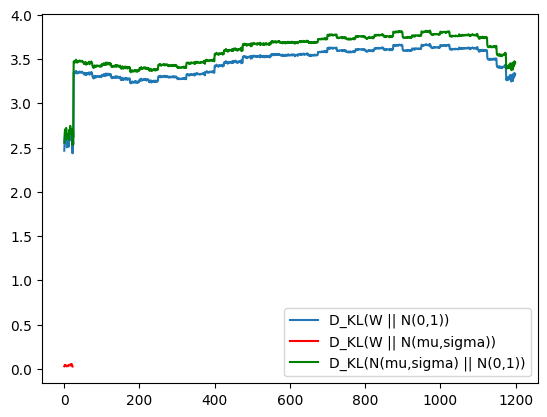

In [ ]:
fig, ax = plt.subplots()
ax.plot(t1, label = 'D_KL(W || N(0,1))')
ax.plot(t2, label = 'D_KL(W || N(mu,sigma))', color = 'red')
ax.plot(t3, label = 'D_KL(N(mu,sigma) || N(0,1))', color = 'green')
plt.legend()


In [ ]:
import run_weight_analysis

In [ ]:
model_shorts

{'small': 'gpt2-small (124M)',
 'medium': 'gpt2-medium (355M)',
 'large': 'gpt2-large (774M)',
 'xl': 'gpt2-xl (1558M)'}

In [ ]:
from run_weight_analysis import model_shorts, main

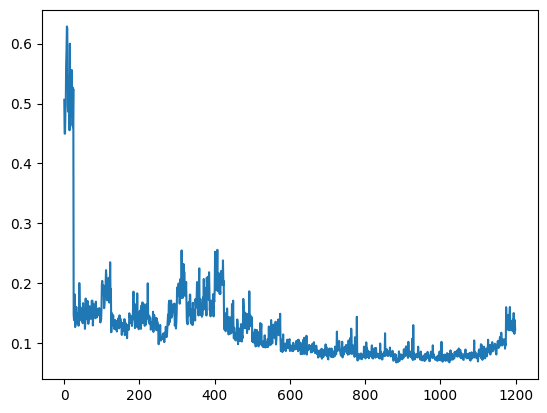

In [ ]:
t1 = np.array([v for v in hb.extract_stats('max').values()])
fig, ax = plt.subplots()
ax.plot(t1,)

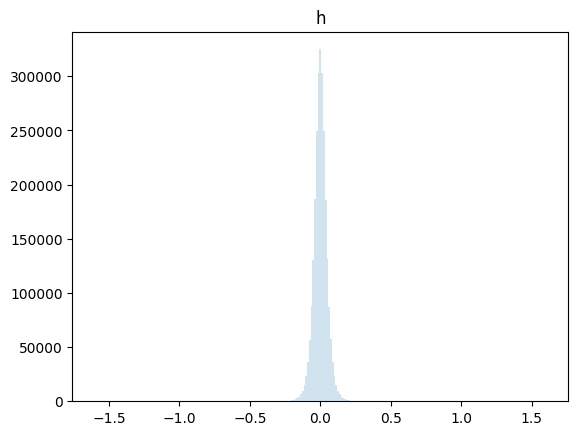

In [ ]:
hb[0,0].draw()